Modelo Booleano

In [ ]:
import pandas as pd
import glob
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

archivos_excel = glob.glob('/content/*.xlsx')

dfs = []

print(f"Archivos Excel encontrados: {archivos_excel}")

for archivo in archivos_excel:
    try:
        partes = archivo.split('/')[-1].replace('.xlsx', '').split('-')
        año = int(partes[0])
        periodo = int(partes[1]) if len(partes) > 1 else 1

        df = pd.read_excel(archivo)
        df['Year'] = año
        df['Period'] = periodo
        dfs.append(df)
        print(f"Cargado: {archivo}")
    except Exception as e:
        print(f"Error al cargar {archivo}: {e}")

if not dfs:
    print("No se pudieron cargar archivos Excel. Por favor, verifica el formato y la ubicación.")
else:
    df_combinado = pd.concat(dfs, ignore_index=True)

    if 'StudentID' not in df_combinado.columns:
        df_combinado['StudentID'] = range(1, len(df_combinado) + 1)
        print("Columna 'StudentID' creada con valores secuenciales (adaptar si ya existe).")

    if 'GPA' not in df_combinado.columns:
        df_combinado['GPA'] = pd.Series([2.5, 3.0, 1.8, 3.5, 2.2]).sample(len(df_combinado), replace=True, random_state=42).values
        print("Columna 'GPA' simulada (adaptar si ya existe).")
    if 'FinancialAid' not in df_combinado.columns:
        df_combinado['FinancialAid'] = pd.Series([True, False]).sample(len(df_combinado), replace=True, random_state=42).values
        print("Columna 'FinancialAid' simulada (adaptar si ya existe).")

    df_combinado = df_combinado.sort_values(by=['StudentID', 'Year', 'Period']).reset_index(drop=True)

    estudiantes_por_periodo = df_combinado.groupby(['Year', 'Period'])['StudentID'].apply(set)

    df_combinado['Desercion'] = False

    todos_años_periodos = sorted(df_combinado[['Year', 'Period']].drop_duplicates().values.tolist())

    for i in range(len(todos_años_periodos) - 1):
        año_actual, periodo_actual = todos_años_periodos[i]
        año_siguiente, periodo_siguiente = todos_años_periodos[i + 1]

        estudiantes_actuales = estudiantes_por_periodo.get((año_actual, periodo_actual), set())
        estudiantes_siguientes = estudiantes_por_periodo.get((año_siguiente, periodo_siguiente), set())

        estudiantes_desertores_en_siguiente_periodo = estudiantes_actuales - estudiantes_siguientes

        df_combinado.loc[
            (df_combinado['Year'] == año_actual)
            & (df_combinado['Period'] == periodo_actual)
            & (df_combinado['StudentID'].isin(estudiantes_desertores_en_siguiente_periodo)),
            'Desercion',
        ] = True

    umbral_gpa_bajo = 2.0
    df_combinado['LowGPA'] = df_combinado['GPA'] < umbral_gpa_bajo

    df_combinado['FinancialIssues'] = ~df_combinado['FinancialAid']

    df_combinado['PrediccionDesercion_Model1'] = df_combinado['LowGPA'] & df_combinado['FinancialIssues']

    df_combinado['PrediccionDesercion_Model2'] = df_combinado['LowGPA'] | df_combinado['FinancialIssues']

    print("\n--- Primeras filas del DataFrame combinado con características y predicciones ---")
    print(df_combinado.head())

    print("\n--- Resumen de la columna 'Desercion' real ---")
    print(df_combinado['Desercion'].value_counts())

    print("\n--- Resumen de predicciones del Modelo Booleano 1 (AND) ---")
    print(df_combinado['PrediccionDesercion_Model1'].value_counts())

    print("\n--- Resumen de predicciones del Modelo Booleano 2 (OR) ---")
    print(df_combinado['PrediccionDesercion_Model2'].value_counts())

    if df_combinado['Desercion'].any():
        print("\n--- Evaluación del Modelo Booleano 1 (AND) ---")
        print(f"Accuracy: {accuracy_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_Model1']):.2f}")
        print(f"Precision: {precision_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_Model1']):.2f}")
        print(f"Recall: {recall_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_Model1']):.2f}")
        print(f"F1-Score: {f1_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_Model1']):.2f}")

        print("\n--- Evaluación del Modelo Booleano 2 (OR) ---")
        print(f"Accuracy: {accuracy_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_Model2']):.2f}")
        print(f"Precision: {precision_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_Model2']):.2f}")
        print(f"Recall: {recall_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_Model2']):.2f}")
        print(f"F1-Score: {f1_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_Model2']):.2f}")
    else:
        print("\nNo hay casos de deserción real ('Desercion' es False para todos) para evaluar los modelos de forma significativa.")

    print("\nEste ejemplo demuestra cómo puedes construir un modelo Booleano básico. Puedes ajustar los umbrales y añadir más características booleanas según la riqueza de tus datos y tu conocimiento del dominio.")

Archivos Excel encontrados: ['/content/2024-1.xlsx', '/content/2022-1.xlsx', '/content/2024-2.xlsx', '/content/2022-2.xlsx', '/content/2023-1.xlsx']
Cargado: /content/2024-1.xlsx
Cargado: /content/2022-1.xlsx
Cargado: /content/2024-2.xlsx
Cargado: /content/2022-2.xlsx
Cargado: /content/2023-1.xlsx
Columna 'StudentID' creada con valores secuenciales (adaptar si ya existe).
Columna 'GPA' simulada (adaptar si ya existe).
Columna 'FinancialAid' simulada (adaptar si ya existe).

--- Primeras filas del DataFrame combinado con características y predicciones ---
    N°                Campus       Sexo       Carnet  \
0  1.0               ROBLEDO  Masculino   23258695.0   
1  2.0               ROBLEDO   Femenino   22258001.0   
2  3.0  FRATERNIDAD MEDELLÍN  Masculino  241588892.0   
3  4.0               ROBLEDO  Masculino   23158004.0   
4  5.0  FRATERNIDAD MEDELLÍN  Masculino   22158003.0   

                 Apellidos y Nombres     Documento    Teléfono Nota 1  \
0      ACEVEDO HIGUITA MAIKOL

In [ ]:
import math

docs = {
    "D1": {"python", "web", "datos"},
    "D2": {"java", "web", "apps"},
    "D3": {"python", "java", "programacion"},
}

def buscar(termino1, operador, termino2=None):
    resultados = []
    for nombre, terminos in docs.items():
        if operador == "AND":
            match = termino1 in terminos and termino2 in terminos
        elif operador == "OR":
            match = termino1 in terminos or termino2 in terminos
        elif operador == "NOT":
            match = termino1 not in terminos

        if match:
            resultados.append(nombre)
    return resultados

print(buscar("python", "AND", "web"))
print(buscar("python", "OR", "java"))
print(buscar("web",    "NOT"))

['D1']
['D1', 'D2', 'D3']
['D3']


Modelo vectorial

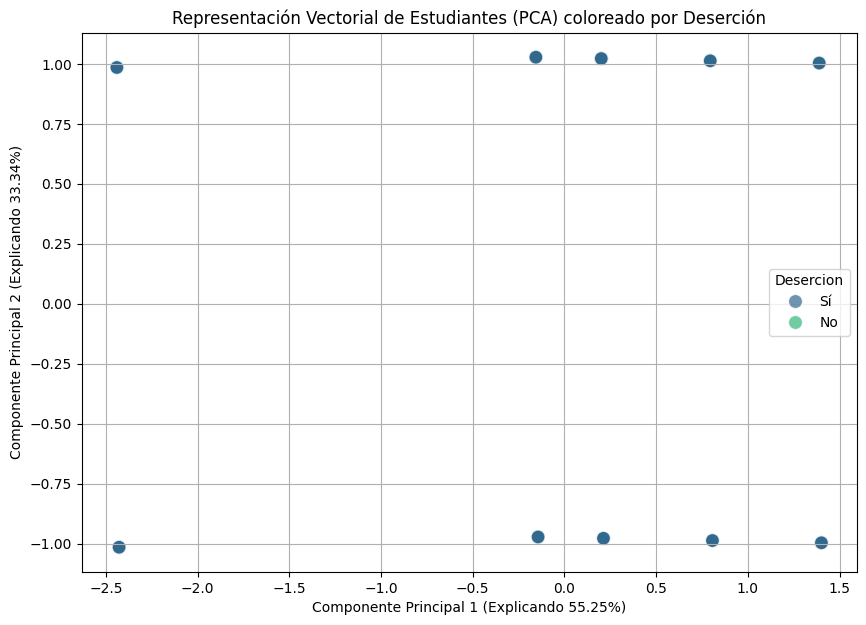


--- Explicación del Modelo Vectorial ---
Hemos transformado algunas características clave de nuestros estudiantes (GPA, bajo GPA, problemas financieros)
en un espacio vectorial. Utilizamos PCA (Análisis de Componentes Principales) para reducir la dimensionalidad
a 2 componentes principales, lo que nos permite visualizar las similitudes y diferencias entre los estudiantes.
Los estudiantes más cercanos en este gráfico son más similares en términos de estas características.
El color indica si el estudiante 'desertó' o no, ayudando a identificar posibles patrones visuales.
La Componente Principal 1 explica el 55.25% de la varianza total explicada.
La Componente Principal 2 explica el 33.34% de la varianza total explicada.
En conjunto, estas dos componentes explican el 88.59% de la varianza.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

if 'combined_df' in locals() and not combined_df.empty:
    caracteristicas = combined_df[['GPA', 'LowGPA', 'FinancialIssues']].copy()
    caracteristicas['LowGPA'] = caracteristicas['LowGPA'].astype(int)
    caracteristicas['FinancialIssues'] = caracteristicas['FinancialIssues'].astype(int)

    caracteristicas.dropna(inplace=True)

    if not caracteristicas.empty:
        escalador = StandardScaler()
        caracteristicas_escaladas = escalador.fit_transform(caracteristicas)

        pca = PCA(n_components=2)
        componentes_principales = pca.fit_transform(caracteristicas_escaladas)

        df_pca = pd.DataFrame(data=componentes_principales, columns=['PC1', 'PC2'])

        df_combinado_filtrado = combined_df.loc[caracteristicas.index]
        df_pca['Desercion'] = df_combinado_filtrado['Desercion'].map({True: 'Sí', False: 'No'})

        plt.figure(figsize=(10, 7))
        sns.scatterplot(
            x='PC1',
            y='PC2',
            hue='Desercion',
            palette='viridis',
            data=df_pca,
            s=100,
            alpha=0.7
        )
        plt.title('Representación Vectorial de Estudiantes (PCA) coloreado por Deserción')
        plt.xlabel(f'Componente Principal 1 (Explicando {pca.explained_variance_ratio_[0]*100:.2f}%)')
        plt.ylabel(f'Componente Principal 2 (Explicando {pca.explained_variance_ratio_[1]*100:.2f}%)')
        plt.grid(True)
        plt.show()

        print("\n--- Explicación del Modelo Vectorial ---")
        print("Hemos transformado algunas características clave de nuestros estudiantes (GPA, bajo GPA, problemas financieros)")
        print("en un espacio vectorial. Utilizamos PCA (Análisis de Componentes Principales) para reducir la dimensionalidad")
        print("a 2 componentes principales, lo que nos permite visualizar las similitudes y diferencias entre los estudiantes.")
        print("Los estudiantes más cercanos en este gráfico son más similares en términos de estas características.")
        print("El color indica si el estudiante 'desertó' o no, ayudando a identificar posibles patrones visuales.")
        print(f"La Componente Principal 1 explica el {pca.explained_variance_ratio_[0]*100:.2f}% de la varianza total explicada.")
        print(f"La Componente Principal 2 explica el {pca.explained_variance_ratio_[1]*100:.2f}% de la varianza total explicada.")
        print(f"En conjunto, estas dos componentes explican el {(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])*100:.2f}% de la varianza.")

    else:
        print("No hay datos suficientes después de la limpieza para realizar el análisis PCA con las características seleccionadas.")
else:
    print("El DataFrame 'combined_df' no se encontró o está vacío. Asegúrate de haber ejecutado las celdas anteriores para cargarlo y procesarlo.")

In [ ]:
if 'pca' in locals() and 'caracteristicas' in locals():
    cargas = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(pca.n_components)],
        index=caracteristicas.columns
    )

    print("\n--- Importancia de las Características en los Componentes Principales ---")
    print(cargas)

    print("\n--- Interpretación ---")
    print("Los valores en esta tabla representan la 'carga' de cada característica original en cada Componente Principal.")
    print("Un valor más grande (en magnitud, ignorando el signo) indica que esa característica contribuye más a ese componente.")
    print("Por ejemplo, si 'GPA' tiene un valor alto en 'PC1', significa que 'GPA' es una característica importante para definir 'PC1'.")
    print("El signo indica la dirección de la relación (positiva o negativa).")
else:
    print("Las variables 'pca' o 'caracteristicas' no se encontraron. Asegúrate de haber ejecutado la celda anterior para realizar el PCA.")


--- Importancia de las Características en los Componentes Principales ---
                      PC1       PC2
GPA              0.707140 -0.011145
LowGPA          -0.707048 -0.019652
FinancialIssues -0.006015  0.999745

--- Interpretación ---
Los valores en esta tabla representan la 'carga' de cada característica original en cada Componente Principal.
Un valor más grande (en magnitud, ignorando el signo) indica que esa característica contribuye más a ese componente.
Por ejemplo, si 'GPA' tiene un valor alto en 'PC1', significa que 'GPA' es una característica importante para definir 'PC1'.
El signo indica la dirección de la relación (positiva o negativa).


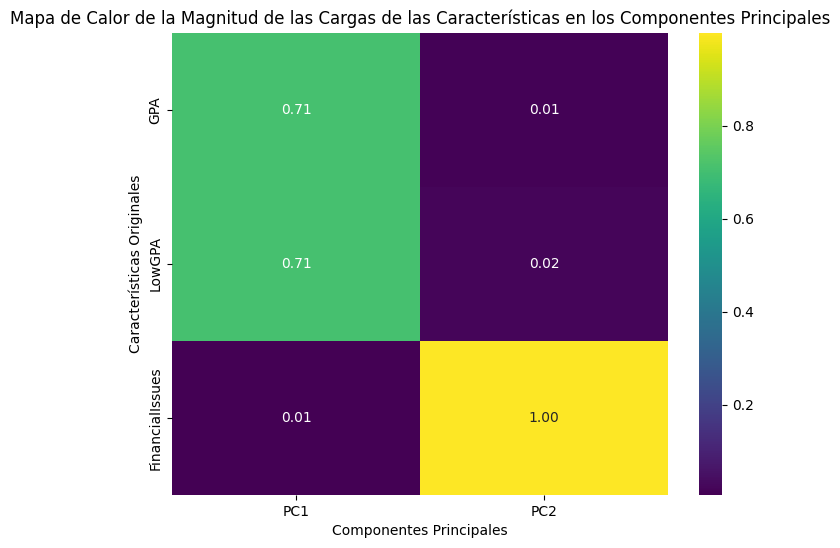


--- Interpretación del Mapa de Calor ---
Este mapa de calor muestra la magnitud (valor absoluto) de la contribución de cada característica original a cada componente principal.
Un color más intenso indica una mayor influencia de esa característica en el componente principal correspondiente.
Puedes usar esto para identificar cuáles características son más importantes para definir cada uno de los Componentes Principales.


In [ ]:
if 'cargas' in locals():
    plt.figure(figsize=(8, 6))
    sns.heatmap(cargas.abs(), annot=True, cmap='viridis', fmt=".2f")
    plt.title('Mapa de Calor de la Magnitud de las Cargas de las Características en los Componentes Principales')
    plt.xlabel('Componentes Principales')
    plt.ylabel('Características Originales')
    plt.show()

    print("\n--- Interpretación del Mapa de Calor ---")
    print("Este mapa de calor muestra la magnitud (valor absoluto) de la contribución de cada característica original a cada componente principal.")
    print("Un color más intenso indica una mayor influencia de esa característica en el componente principal correspondiente.")
    print("Puedes usar esto para identificar cuáles características son más importantes para definir cada uno de los Componentes Principales.")
else:
    print("La variable 'cargas' no se encontró. Asegúrate de haber ejecutado la celda anterior para calcular las cargas.")


In [ ]:
import math

# --- Documentos y consulta ---
docs = {
    "D1": ["gato", "gato", "perro"],
    "D2": ["perro", "perro", "veterinario"],
}
query = ["gato", "perro"]

vocabulario = sorted(set(w for d in docs.values() for w in d) | set(query))
N = len(docs)

# --- TF: frecuencia de cada término en cada doc ---
def tf(termino, doc):
    return doc.count(termino) / len(doc)

# --- IDF: qué tan raro es el término en la colección ---
def idf(termino):
    docs_con_termino = sum(1 for d in docs.values() if termino in d)
    return math.log(N / (1 + docs_con_termino)) + 1

# --- Vector TF-IDF ---
def vector(doc):
    return [tf(t, doc) * idf(t) for t in vocabulario]

# --- Similitud coseno ---
def coseno(v1, v2):
    dot = sum(a * b for a, b in zip(v1, v2))
    mag1 = math.sqrt(sum(a**2 for a in v1))
    mag2 = math.sqrt(sum(b**2 for b in v2))
    return dot / (mag1 * mag2) if mag1 and mag2 else 0

# --- Calcular y rankear ---
vec_query = vector(query)
ranking = {}
for nombre, doc in docs.items():
    vec_doc = vector(doc)
    ranking[nombre] = coseno(vec_query, vec_doc)

print("Vocabulario:", vocabulario)
print()
for doc, sim in sorted(ranking.items(), key=lambda x: -x[1]):
    print(f"  {doc}: similitud = {sim:.4f}")

Vocabulario: ['gato', 'perro', 'veterinario']

  D1: similitud = 0.9695
  D2: similitud = 0.3911


Modelo Probabilístico

In [ ]:
import numpy as np
from collections import Counter
import math
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

if 'df_combinado' not in locals() or df_combinado.empty:
    print("El DataFrame 'df_combinado' no se encontró o está vacío. Asegúrate de haber ejecutado las celdas anteriores para cargarlo y procesarlo.")
else:
    corpus_de_estudiantes = []
    for index, row in df_combinado.iterrows():
        doc_terms = []
        if row['LowGPA']:
            doc_terms.append('bajo_gpa')
        else:
            doc_terms.append('gpa_normal')
        if row['FinancialIssues']:
            doc_terms.append('problemas_financieros')
        else:
            doc_terms.append('sin_problemas_financieros')
        corpus_de_estudiantes.append(doc_terms)

    document_ids = df_combinado.index.tolist()

    def calculate_idf(corpus):
        N = len(corpus)
        doc_freq = Counter()
        for doc in corpus:
            doc_freq.update(set(doc))

        idf_values = {}
        for term, freq in doc_freq.items():
            idf_values[term] = math.log((N - freq + 0.5) / (freq + 0.5) + 1)
        return idf_values

    idf_scores = calculate_idf(corpus_de_estudiantes)

    doc_lengths = [len(doc) for doc in corpus_de_estudiantes]
    avg_doc_len = sum(doc_lengths) / len(doc_lengths)

    def bm25_score(document_terms, query_terms, avg_doc_len, doc_len, k1, b, idf_values):
        score = 0
        term_counts_doc = Counter(document_terms)

        for term in query_terms:
            if term in term_counts_doc and term in idf_values:
                idf = idf_values[term]
                tf_doc = term_counts_doc[term]
                numerator = tf_doc * (k1 + 1)
                denominator = tf_doc + k1 * (1 - b + b * (doc_len / avg_doc_len))
                score += idf * (numerator / denominator)
        return score

    query_terms_desercion = ['bajo_gpa', 'problemas_financieros']

    k1 = 1.5
    b = 0.75

    bm25_scores = []
    for i, doc_terms in enumerate(corpus_de_estudiantes):
        score = bm25_score(doc_terms, query_terms_desercion, avg_doc_len, doc_lengths[i], k1, b, idf_scores)
        bm25_scores.append(score)

    df_combinado['BM25_Score_Desercion'] = bm25_scores

    print("\n--- Primeras filas del DataFrame con scores BM25 ---")
    print(df_combinado[['LowGPA', 'FinancialIssues', 'Desercion', 'BM25_Score_Desercion']].head())

    umbral_bm25 = df_combinado['BM25_Score_Desercion'].median()
    df_combinado['PrediccionDesercion_BM25'] = df_combinado['BM25_Score_Desercion'] > umbral_bm25

    print(f"\nUmbral BM25 para deserción (mediana de scores): {umbral_bm25:.4f}")

    if df_combinado['Desercion'].any():
        print("\n--- Evaluación del Modelo Probabilístico (BM25) ---")
        print(f"Accuracy: {accuracy_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_BM25']):.2f}")
        print(f"Precision: {precision_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_BM25']):.2f}")
        print(f"Recall: {recall_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_BM25']):.2f}")
        print(f"F1-Score: {f1_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_BM25']):.2f}")
    else:
        print("\nNo hay casos de deserción real ('Desercion' es False para todos) para evaluar el modelo BM25 de forma significativa.")

    print("\n--- Explicación del Modelo Probabilístico (BM25) ---")
    print("Este ejemplo adapta el modelo probabilístico BM25 (Best Match 25), comúnmente usado en motores de búsqueda,")
    print("para identificar estudiantes con características que los hacen propensos a la deserción.")
    print("Cada estudiante se considera un 'documento' compuesto por 'términos' que describen sus características (bajo GPA, problemas financieros).")
    print("La 'consulta' representa el perfil de un estudiante en riesgo de deserción ('bajo_gpa', 'problemas_financieros').")
    print("El score BM25 mide qué tan 'relevante' es cada estudiante a esta consulta, basándose en la frecuencia de los términos en el estudiante (TF)")
    print("y la rareza de esos términos en el conjunto de todos los estudiantes (IDF).")
    print("Un score BM25 más alto indica que el estudiante se ajusta más al perfil de riesgo.")
    print(f"Para la evaluación, se ha establecido un umbral de {umbral_bm25:.4f} (la mediana de los scores BM25).")
    print("Los estudiantes con un score BM25 superior a este umbral son predichos como desertores.")


--- Primeras filas del DataFrame con scores BM25 ---
   LowGPA  FinancialIssues  Desercion  BM25_Score_Desercion
0   False            False       True              0.000000
1   False             True       True              0.704092
2    True            False       True              1.669306
3   False            False       True              0.000000
4   False            False       True              0.000000

Umbral BM25 para deserción (mediana de scores): 0.7041

--- Evaluación del Modelo Probabilístico (BM25) ---
Accuracy: 0.37
Precision: 0.70
Recall: 0.19
F1-Score: 0.30

--- Explicación del Modelo Probabilístico (BM25) ---
Este ejemplo adapta el modelo probabilístico BM25 (Best Match 25), comúnmente usado en motores de búsqueda,
para identificar estudiantes con características que los hacen propensos a la deserción.
Cada estudiante se considera un 'documento' compuesto por 'términos' que describen sus características (bajo GPA, problemas financieros).
La 'consulta' representa el p

In [ ]:
from sklearn.metrics import precision_score

if 'df_combinado' in locals() and not df_combinado.empty and 'Desercion' in df_combinado.columns and 'PrediccionDesercion_BM25' in df_combinado.columns:
    if df_combinado['Desercion'].any():
        bm25_precision = precision_score(df_combinado['Desercion'], df_combinado['PrediccionDesercion_BM25'])
        print(f"\nPrecisión del Modelo Probabilístico (BM25): {bm25_precision:.2f}")
    else:
        print("No hay casos de deserción real para calcular la precisión del modelo BM25.")
else:
    print("Las columnas necesarias para calcular la precisión del modelo BM25 no están disponibles en 'df_combinado'.")


Precisión del Modelo Probabilístico (BM25): 0.70


In [ ]:
import pandas as pd
import numpy as np
import gensim
from gensim import corpora, models
import nltk
from sklearn.metrics.pairwise import cosine_similarity

# Asegurar que NLTK data esté descargado (solo se necesita una vez)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError: # Changed from nltk.downloader.DownloadError
    nltk.download('punkt')

print("--- Demostración de Procesamiento, Análisis y Recuperación de Información con Gensim y NLTK/scikit-learn ---")

# Verificamos que df_combinado esté disponible del procesamiento anterior
if 'df_combinado' not in locals() or df_combinado.empty:
    print("El DataFrame 'df_combinado' no se encontró o está vacío. Asegúrate de haber ejecutado las celdas anteriores para cargarlo y procesarlo.")
else:
    # 1. Procesamiento de Información: Creación de un corpus a partir de características
    # Reutilizamos la lógica del corpus de estudiantes del modelo probabilístico.
    # Cada estudiante es un "documento" y sus características son los "términos".
    corpus_de_estudiantes_terms = []
    for index, row in df_combinado.iterrows():
        doc_terms = []
        if row['LowGPA']:
            doc_terms.append('bajo_gpa')
        else:
            doc_terms.append('gpa_normal')
        if row['FinancialIssues']:
            doc_terms.append('problemas_financieros')
        else:
            doc_terms.append('sin_problemas_financieros')
        corpus_de_estudiantes_terms.append(doc_terms)

    # NLTK: En un escenario con texto libre (ej. comentarios), NLTK se usaría para tokenización, stemming, etc.
    # Por ejemplo:
    # from nltk.tokenize import word_tokenize
    # some_text = "El estudiante con bajo GPA y problemas financieros está en riesgo."
    # tokens_nltk = word_tokenize(some_text.lower())
    # print(f"\nEjemplo de tokenización con NLTK: {tokens_nltk}")

    # Gensim: Crear un diccionario a partir de los términos del corpus.
    dictionary = corpora.Dictionary(corpus_de_estudiantes_terms)
    # Crear un corpus BoW (Bag-of-Words) donde cada documento es una lista de (id_término, frecuencia).
    corpus_bow = [dictionary.doc2bow(doc) for doc in corpus_de_estudiantes_terms]

    print(f"\nNúmero de documentos (estudiantes) en el corpus: {len(corpus_bow)}")
    print(f"Número de términos únicos en el diccionario: {len(dictionary)}")
    # print(f"Primer documento en formato BoW: {corpus_bow[0]}")

    # 2. Análisis de Información: Transformación TF-IDF con Gensim
    # TF-IDF (Term Frequency-Inverse Document Frequency) pondera la importancia de cada término.
    # Un término es más importante si aparece mucho en un documento pero es raro en el resto del corpus.
    tfidf_model = models.TfidfModel(corpus_bow)
    corpus_tfidf = tfidf_model[corpus_bow]

    # Convertir el corpus TF-IDF de Gensim a una matriz NumPy para usar con scikit-learn.
    num_terms = len(dictionary)
    tfidf_matrix = np.zeros((len(corpus_tfidf), num_terms))
    for i, doc in enumerate(corpus_tfidf):
        for term_id, tfidf_val in doc:
            tfidf_matrix[i, term_id] = tfidf_val

    print(f"\nDimensión de la matriz TF-IDF (Estudiantes x Términos): {tfidf_matrix.shape}")
    # print(f"Vector TF-IDF para el primer estudiante:\n{tfidf_matrix[0]}")

    # 3. Recuperación Eficiente de Información Relevante: Búsqueda por similitud
    # Definimos una "consulta" que representa el perfil de un estudiante con riesgo de deserción.
    query_terms_desercion_gensim = ['bajo_gpa', 'problemas_financieros']
    # Convertir la consulta a formato BoW y luego a TF-IDF usando los modelos ya creados.
    query_bow = dictionary.doc2bow(query_terms_desercion_gensim)
    query_tfidf = tfidf_model[query_bow]

    # Convertir la consulta TF-IDF a un vector NumPy para el cálculo de similitud.
    query_vector = np.zeros(num_terms)
    for term_id, tfidf_val in query_tfidf:
        query_vector[term_id] = tfidf_val

    # Calcular la similitud coseno entre la consulta y todos los vectores TF-IDF de los estudiantes.
    # Usamos `sklearn.metrics.pairwise.cosine_similarity` por su eficiencia.
    if len(tfidf_matrix) > 0 and num_terms > 0:
        similarities = cosine_similarity(query_vector.reshape(1, -1), tfidf_matrix)
        similarities_flat = similarities.flatten()

        # Añadir las similitudes al DataFrame para un análisis fácil.
        df_combinado['TFIDF_Similarity_Desercion'] = similarities_flat

        # Mostrar los estudiantes con mayor similitud al perfil de deserción.
        print("\n--- Top 5 Estudiantes más similares al perfil de deserción (TF-IDF y Similitud Coseno) ---")
        top_n = 5
        top_students = df_combinado.nlargest(top_n, 'TFIDF_Similarity_Desercion')
        print(top_students[['StudentID', 'LowGPA', 'FinancialIssues', 'TFIDF_Similarity_Desercion', 'Desercion']])

        print(f"\nEstos son los {top_n} estudiantes con mayor similitud TF-IDF al perfil de deserción. Podemos observar si sus valores de 'Desercion' real coinciden con esta predicción por similitud. Un valor de similitud más alto indica que el estudiante comparte más características importantes con el perfil de riesgo.")
    else:
        print("No se puede calcular la similitud coseno, la matriz TF-IDF está vacía o tiene dimensiones inválidas. Asegúrate de que hay datos en 'df_combinado'.")

    print("\n--- Explicación del Rol de las Librerías ---")
    print("**Pandas y Numpy:** Se usan para la manipulación y el almacenamiento eficiente de los datos tabulares y las matrices numéricas (TF-IDF).")
    print("**NLTK (Natural Language Toolkit):** Aunque en este ejemplo los 'términos' ya están predefinidos, NLTK sería fundamental para tareas de procesamiento de lenguaje natural más complejas, como la tokenización, eliminación de 'stop words' o lematización, si tuviéramos datos textuales no estructurados (ej. comentarios de estudiantes).")
    print("**Gensim:** Se utiliza para construir el diccionario de términos, crear el corpus de documentos y aplicar el modelo TF-IDF, transformando las características de los estudiantes en representaciones vectoriales ponderadas.")
    print("**Scikit-learn:** Se usa para calcular eficientemente la similitud coseno entre los vectores TF-IDF. Esto permite cuantificar qué tan 'cercano' es cada estudiante a la 'consulta' del perfil de deserción, facilitando la recuperación de información relevante.")
    print("Este enfoque proporciona una base para el análisis y la recuperación de información basada en la importancia contextual de las características de los estudiantes.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


--- Demostración de Procesamiento, Análisis y Recuperación de Información con Gensim y NLTK/scikit-learn ---

Número de documentos (estudiantes) en el corpus: 2847
Número de términos únicos en el diccionario: 4

Dimensión de la matriz TF-IDF (Estudiantes x Términos): (2847, 4)

--- Top 5 Estudiantes más similares al perfil de deserción (TF-IDF y Similitud Coseno) ---
    StudentID  LowGPA  FinancialIssues  TFIDF_Similarity_Desercion  Desercion
25         26    True             True                         1.0       True
26         27    True             True                         1.0       True
34         35    True             True                         1.0       True
36         37    True             True                         1.0       True
89         90    True             True                         1.0       True

Estos son los 5 estudiantes con mayor similitud TF-IDF al perfil de deserción. Podemos observar si sus valores de 'Desercion' real coinciden con esta predicción 

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.1 MB/s eta 0:00:00



--- Generación de Gráficos de Resultados ---


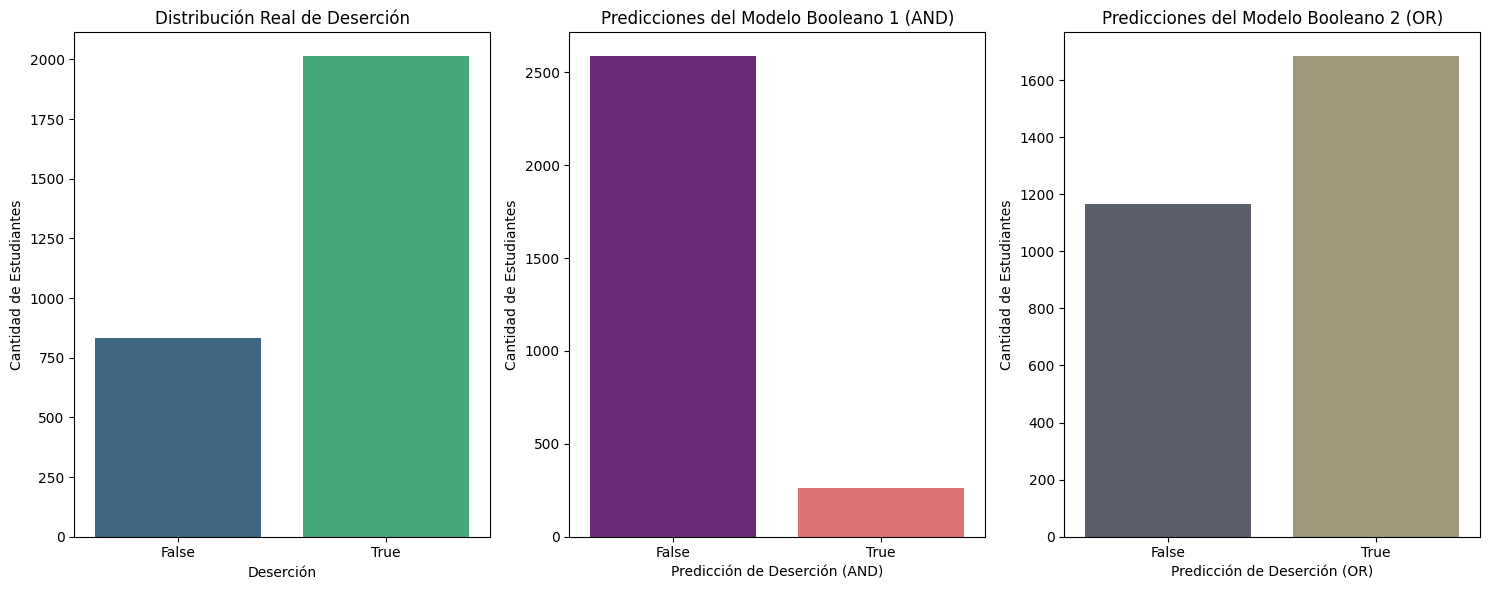


--- Interpretación de Gráficos del Modelo Booleano ---
Estos gráficos de barras muestran la distribución de la deserción real y las predicciones de los dos modelos booleanos. Puedes comparar visualmente cuántos estudiantes son clasificados como desertores por cada modelo en contraste con la realidad.


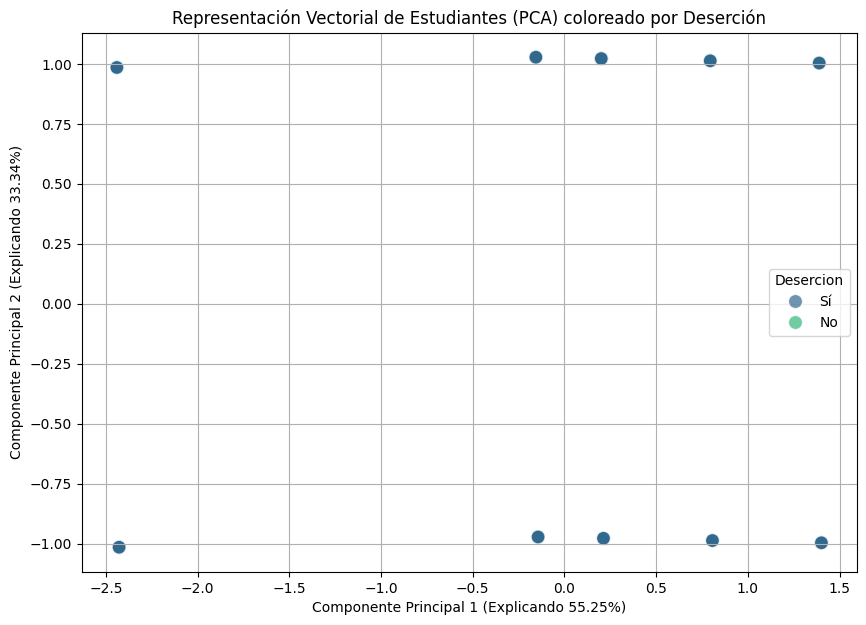


--- Interpretación de Gráfico del Modelo Vectorial (PCA) ---
Este gráfico muestra a los estudiantes en un espacio bidimensional (reducción de PCA). Los estudiantes con características similares están más cerca entre sí. Los colores indican si el estudiante desertó o no, lo que puede revelar visualmente si las características principales están relacionadas con la deserción.


/tmp/ipykernel_14751/1808688117.py:86: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_combinado['BM25_Score_Desercion'], kde=True, bins=30, palette='plasma')


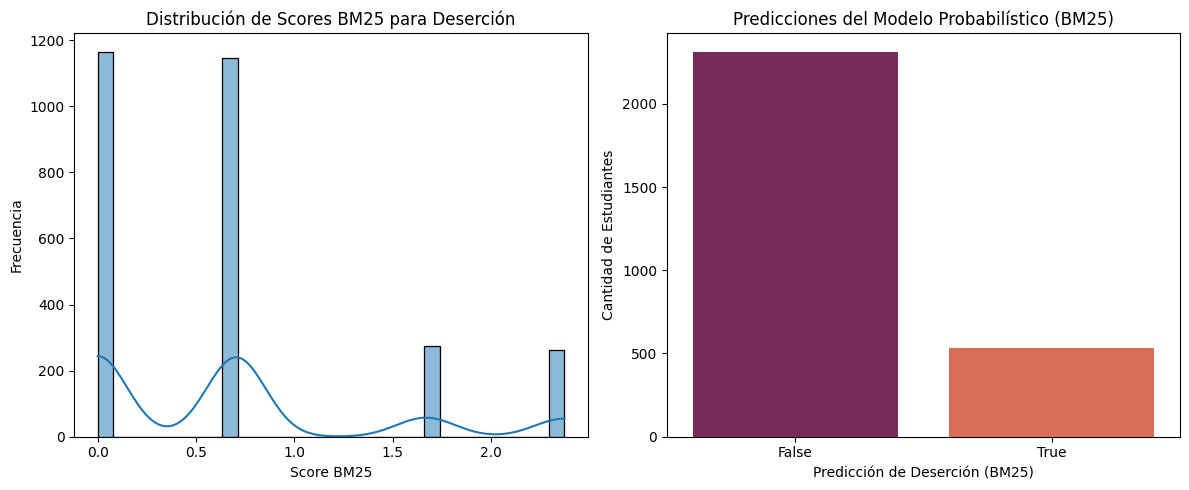


--- Interpretación de Gráficos del Modelo Probabilístico (BM25) ---
El histograma muestra cómo se distribuyen los scores BM25 entre los estudiantes. Un score más alto indica una mayor similitud con el perfil de deserción. El gráfico de barras de predicción muestra cuántos estudiantes son marcados como posibles desertores por este modelo basado en el umbral mediano.

--- Fin de la Sección de Gráficos ---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\n--- Generación de Gráficos de Resultados ---")

if 'df_combinado' not in locals() or df_combinado.empty:
    print("El DataFrame 'df_combinado' no se encontró o está vacío. Asegúrate de haber ejecutado las celdas anteriores para cargarlo y procesarlo.")
else:
    # 1. Gráficos para el Modelo Booleano
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 3, 1)
    sns.countplot(x='Desercion', data=df_combinado, palette='viridis', hue='Desercion', legend=False)
    plt.title('Distribución Real de Deserción')
    plt.xlabel('Deserción')
    plt.ylabel('Cantidad de Estudiantes')

    plt.subplot(1, 3, 2)
    sns.countplot(x='PrediccionDesercion_Model1', data=df_combinado, palette='magma', hue='PrediccionDesercion_Model1', legend=False)
    plt.title('Predicciones del Modelo Booleano 1 (AND)')
    plt.xlabel('Predicción de Deserción (AND)')
    plt.ylabel('Cantidad de Estudiantes')

    plt.subplot(1, 3, 3)
    sns.countplot(x='PrediccionDesercion_Model2', data=df_combinado, palette='cividis', hue='PrediccionDesercion_Model2', legend=False)
    plt.title('Predicciones del Modelo Booleano 2 (OR)')
    plt.xlabel('Predicción de Deserción (OR)')
    plt.ylabel('Cantidad de Estudiantes')

    plt.tight_layout()
    plt.show()

    print("\n--- Interpretación de Gráficos del Modelo Booleano ---")
    print("Estos gráficos de barras muestran la distribución de la deserción real y las predicciones de los dos modelos booleanos. Puedes comparar visualmente cuántos estudiantes son clasificados como desertores por cada modelo en contraste con la realidad.")

    # 2. Gráfico para el Modelo Vectorial (PCA)
    # Recrear el PCA si las variables no están disponibles (aunque deberían estarlo)
    if 'pca' not in locals() or 'caracteristicas' not in locals():
        print("Las variables 'pca' o 'caracteristicas' no se encontraron. Recreando PCA para el gráfico...")
        caracteristicas = df_combinado[['GPA', 'LowGPA', 'FinancialIssues']].copy()
        caracteristicas['LowGPA'] = caracteristicas['LowGPA'].astype(int)
        caracteristicas['FinancialIssues'] = caracteristicas['FinancialIssues'].astype(int)
        caracteristicas.dropna(inplace=True)

        if not caracteristicas.empty:
            escalador = StandardScaler()
            caracteristicas_escaladas = escalador.fit_transform(caracteristicas)
            pca = PCA(n_components=2)
            componentes_principales = pca.fit_transform(caracteristicas_escaladas)
            df_pca = pd.DataFrame(data=componentes_principales, columns=['PC1', 'PC2'])
            df_combinado_filtrado = df_combinado.loc[caracteristicas.index]
            df_pca['Desercion'] = df_combinado_filtrado['Desercion'].map({True: 'Sí', False: 'No'})
        else:
            print("No hay datos suficientes después de la limpieza para realizar el análisis PCA para el gráfico.")


    if 'df_pca' in locals() and not df_pca.empty:
        plt.figure(figsize=(10, 7))
        sns.scatterplot(
            x='PC1',
            y='PC2',
            hue='Desercion',
            palette='viridis',
            data=df_pca,
            s=100,
            alpha=0.7
        )
        plt.title('Representación Vectorial de Estudiantes (PCA) coloreado por Deserción')
        plt.xlabel(f'Componente Principal 1 (Explicando {pca.explained_variance_ratio_[0]*100:.2f}%)')
        plt.ylabel(f'Componente Principal 2 (Explicando {pca.explained_variance_ratio_[1]*100:.2f}%)')
        plt.grid(True)
        plt.show()

        print("\n--- Interpretación de Gráfico del Modelo Vectorial (PCA) ---")
        print("Este gráfico muestra a los estudiantes en un espacio bidimensional (reducción de PCA). Los estudiantes con características similares están más cerca entre sí. Los colores indican si el estudiante desertó o no, lo que puede revelar visualmente si las características principales están relacionadas con la deserción.")

    # 3. Gráficos para el Modelo Probabilístico (BM25)
    if 'BM25_Score_Desercion' in df_combinado.columns:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(df_combinado['BM25_Score_Desercion'], kde=True, bins=30, palette='plasma')
        plt.title('Distribución de Scores BM25 para Deserción')
        plt.xlabel('Score BM25')
        plt.ylabel('Frecuencia')

        plt.subplot(1, 2, 2)
        sns.countplot(x='PrediccionDesercion_BM25', data=df_combinado, palette='rocket', hue='PrediccionDesercion_BM25', legend=False)
        plt.title('Predicciones del Modelo Probabilístico (BM25)')
        plt.xlabel('Predicción de Deserción (BM25)')
        plt.ylabel('Cantidad de Estudiantes')

        plt.tight_layout()
        plt.show()

        print("\n--- Interpretación de Gráficos del Modelo Probabilístico (BM25) ---")
        print("El histograma muestra cómo se distribuyen los scores BM25 entre los estudiantes. Un score más alto indica una mayor similitud con el perfil de deserción. El gráfico de barras de predicción muestra cuántos estudiantes son marcados como posibles desertores por este modelo basado en el umbral mediano.")

    else:
        print("La columna 'BM25_Score_Desercion' no se encontró. Asegúrate de haber ejecutado la celda del Modelo Probabilístico.")

print("\n--- Fin de la Sección de Gráficos ---")

In [9]:
import pandas as pd
data = pd.read_excel("/content/drive/MyDrive/Estructuras de Datos/TRABAJO_21_4_26/2024-2.xlsx")


In [8]:
columns_to_drop = ['Apellidos y Nombres', 'Documento', 'Teléfono']
data = data.drop(columns=columns_to_drop, errors='ignore')
display(data.head(5))

,N°,Carné,Nota 1,Nota 2,Nota 3,Nota 4,Nota 5,Nota 6,Final,Resultado
0,1,23258695,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Canceló
1,2,22258001,0.1,0.0,0.0,0.0,0.0,0.0,0.0,Reprobó Inasistencia
2,3,24158103,3.7,3.0,1.7,1.0,4.5,0.0,2.8,Reprobó
3,4,24158104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Canceló
4,5,24158105,3.9,3.3,1.6,4.6,4.7,4.1,3.5,Aprobó
